# Small Angle Light Scattering

# Aim:

To determine the particle size in a colloidal solution (polystyrene beads) using scattering
of light.

# Apparatus Used:

* Diode Laser
* Laser Power Supply
* Optical Bench
* Optical rail
* Aperture
* Goniometer
* Photodiode and detector
* Cuvette
* Colloidal solution of polystyrene beads




# Theory:

Scattering is the redirection of light that occurs when an electromagnetic (EM) wave encounters an obstacle or non-homogeneity, such as a scattering particle. As the EM wave interacts with the particle, the electric orbits are perturbed at the same frequency as the incident field. These oscillations in the electron cloud result in an induced dipole moment in the molecule, which in turn emits electromagnetic radiation in different directions.

### Types of Scattering

#### 1. Elastic Scattering
Elastic scattering occurs when there is no difference in the energy (and thus the frequency) of the incident and scattered electromagnetic waves. The two primary examples are:

* **Rayleigh Scattering**: Occurs when the particle size ($r$) of the scatterer is much smaller than the incident light wavelength, defined by the condition $2\pi r/\lambda \ll 1$. It happens uniformly in all directions and is strongly dependent on the wavelength of incident light, which is why the sky appears blue.
* **Mie Scattering**: Occurs when the particle size is equivalent to or greater than the wavelength of the incident light, defined as $2\pi r/\lambda \ge 1$. Unlike Rayleigh scattering, Mie scattering happens mostly in the forward direction and is not highly dependent on wavelength, which is the reason clouds appear white.



#### 2. Inelastic Scattering
In inelastic scattering, the energy and frequency of the scattered light are not the same as the incident light.
* Examples include **Raman scattering** and **Compton scattering**.

## Working Principle: Guinier's Approximation

Working with nanoscale structures is often difficult because they cannot be seen with the naked eye, and techniques like electron microscopy (SEM/TEM) may not reflect the sample's natural conditions. **Small Angle Scattering (SAS)**, a limiting case of Mie Scattering, provides an indirect characterization method to determine particle size using a macroscopic amount of sample.

### The Scattering Vector ($\vec{q}$)
The geometry of the scattering is defined by the wave vectors of the incident light ($\vec{K_i}$) and the scattered light ($\vec{K_s}$). The difference between these vectors is the scattering vector $\vec{q}$:

$$\vec{q} = \vec{K_s} - \vec{K_i}$$

The magnitude of this vector is related to the scattering angle $\theta$ and the wavelength $\lambda$ of the laser by the following equation:

$$|\vec{q}| = \frac{4\pi}{\lambda} \sin\left(\frac{\theta}{2}\right)$$



### Guinier's Plot and Radius of Gyration ($R_g$)
Guinier's approximation allows us to find the **Radius of Gyration ($R_g$)** of a molecule from its scattering profile at low angles (small $q$). The intensity $I(q)$ is approximated as:

$$I(q) = I(0) \exp\left(-\frac{1}{3} q^2 R_g^2\right)$$

Where:
* $I(0)$ is the intensity at the zero scattering angle ($q=0$).
* $I(q)$ is the intensity measured at a specific scattering vector $q$.

Because of the exponential nature of this relationship, we can linearize the equation by taking the natural logarithm:

$$\ln(I(q)) = \ln(I(0)) - \frac{1}{3} R_g^2 q^2$$

By plotting $\ln(I)$ vs. $q^2$, we create a **Guinier Plot**. The slope ($m$) of the linear fit in the "Guinier region" is used to determine $R_g$:

$$\text{Slope } (m) = -\frac{1}{3} R_g^2 \implies R_g = \sqrt{-3m}$$

### Determining Physical Particle Size
For particles considered as hard spheres (such as polystyrene beads), the true physical radius ($R$) is related to the radius of gyration by:

$$R = \sqrt{\frac{5}{3}} R_g$$

Finally, the diameter of the particle is simply $D = 2R$.

### Validation Criteria
To ensure the Guinier approximation is valid for the chosen data points, the following condition must be met for the maximum $q$ value ($q_{max}$) used in the linear regression:

$$q_{max} \times R_g < 1.3$$

# Analysis

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

lambda_laser = 63e-8  # m

In [20]:
data = pd.read_csv("Experiment 1.csv")
angle = data["Total"].values # degrees
zero_error = 288.4833333
net = angle - zero_error
intensity = data["Reading (uA)"].values


In [21]:
theta = np.deg2rad(angle - zero_error)
q = (4*np.pi/lambda_laser) * np.sin(theta/2)
logI = np.log(intensity)
q2 = q**2

In [22]:
found = False
for start in range(len(q)-5):
  end = start + 4
  x = q2[start:end]
  y = logI[start:end]
  slope, intercept, r, p, slope_err = linregress(x, y)
  Rg = np.sqrt(-3*slope)   # slope relation
  Rg_err = (3/(2*Rg))*slope_err
  q_max = q[end - 1]
  if q_max*Rg < 1.3:
    found = True
    best_slice = slice(start, end)
    break

In [23]:
x_fit = q2[best_slice]
y_fit = logI[best_slice]

# Sphere radius from Rg
R = np.sqrt(5/3) * Rg
R_err = np.sqrt(5/3) * Rg_err

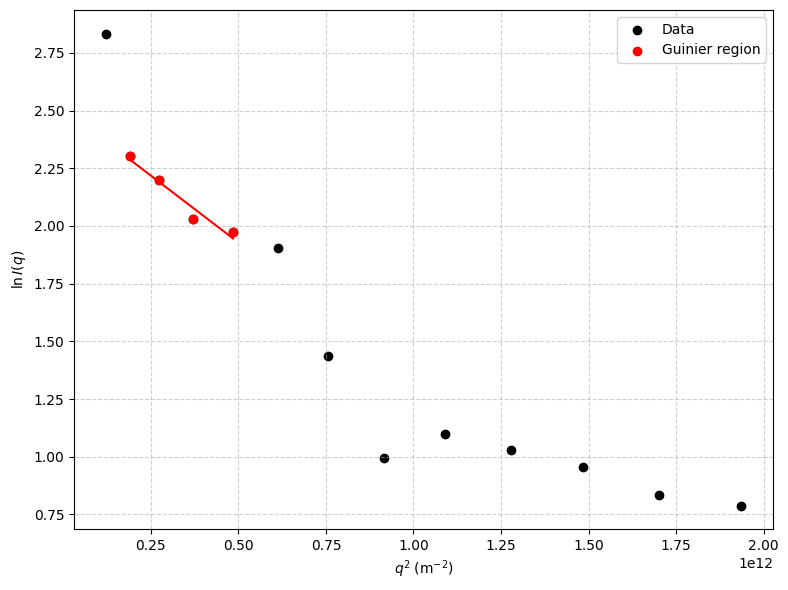

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(q2, logI, color="black", label="Data")
plt.scatter(x_fit, y_fit, color="red", zorder=3, label="Guinier region")

q2_line = np.linspace(x_fit.min(), x_fit.max(), 200)
plt.plot(q2_line, intercept + slope*q2_line, color="red")

plt.xlabel(r"$q^2\;(\mathrm{m^{-2}})$")
plt.ylabel(r"$\ln I(q)$")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
print(f"Slope = {slope:.3e} ± {slope_err:.3e}")
print(f"Rg = {Rg:.3e} ± {Rg_err:.3e} m")
print(f"q_max * Rg = {q[end-1] * Rg:.4f}")
print(f"Particle radius R = {R:.3e} ± {R_err:.3e} m")

Slope = -1.160e-12 ± 1.889e-13
Rg = 1.865e-06 ± 1.519e-07 m
q_max * Rg = 1.2984
Particle radius R = 2.408e-06 ± 1.961e-07 m


# Results:

Slope = $-1.60 \times 10^{-12} \pm 1.889 \times 10^{-13}$ \
$R_g = 1.865 \pm 0.152 \, \, \mu m$ \
$q_{max} \times R_g = 1.2984$ \
Particle Radius = $2.408 \pm 0.196 \, \mu m$